# analyze_exported_npz notebook
Self-contained notebook for NPZ analysis (no external Python module dependency).

- One plotting block per cell.
- Relevant variables are defined at the top of each plotting cell.
- Re-run the data-prep cell after changing settings in the setup cell.



In [21]:
import sys
import matplotlib.pyplot as plt

from pathlib import Path
import re
import warnings

import numpy as np
from scipy.signal import find_peaks


# -------------------------
# Input selection
# -------------------------
NPZ_DIR = Path("npz_exports_zero_mean")
NPZ_GLOB = "*.npz"
NPZ_RECURSIVE = True


# -------------------------
# Plot/analysis settings
# -------------------------
FIRST_WINDOW_SECONDS = 10.0
NORMALIZE_SPECTRA = True
SPECTRUM_NORM_EPS = 1e-12
SPECTRUM_PLOT_MAX_HZ = 5.0
DOM_FREQ_MIN_HZ = 0.05
DOM_FREQ_MAX_HZ = 5.0
DOM_FREQ_WINDOW_SECONDS = 6.0
PHASE_MEAN_BINS = 48
PHASE_MIN_SAMPLES_PER_BIN = 10


# -------------------------
# Physical constants
# -------------------------
D = 0.1
L = 1.0
RUO = 1025.0
FN = 1.119
M = 16.79
K = (2.0 * np.pi * FN) ** 2 * M
ADDED_MASS_COEFF = 1.0
REF_CA_FOR_FN_LINE = 1.0


# -------------------------
# Force/drag labeling
# -------------------------
USE_RAW_FORCE_SIGNALS = True
CF_NAME = "Total CF force"
CF_FORCE_MODE_LABEL = "Fy2 - Fy1 + (m + ma) * y_ddot"
DRAG_NAME = "Drag coefficient"


def _use_raw_force_signals() -> bool:
    return bool(USE_RAW_FORCE_SIGNALS)


def _cf_name() -> str:
    return str(CF_NAME)


def _drag_name() -> str:
    return str(DRAG_NAME)


def _cf_force_mode_label() -> str:
    return str(CF_FORCE_MODE_LABEL)


def _cf_label() -> str:
    if _use_raw_force_signals():
        return "CF force (N)"
    return "CF force coefficient (-)"


def _drag_label() -> str:
    return "Drag coefficient (-)"


def _norm_name(name: str) -> str:
    return "".join(ch for ch in str(name).lower() if ch.isalnum())


def _extract_test_number(path: Path) -> int | None:
    m = re.search(r"test(\d+)", str(path.stem).lower())
    if not m:
        return None
    try:
        return int(m.group(1))
    except ValueError:
        return None


def _resolve_npz_files() -> list[Path]:
    base = Path(NPZ_DIR)
    if not base.exists():
        raise FileNotFoundError(f"NPZ folder not found: {base.resolve()}")
    files = sorted(base.rglob(NPZ_GLOB) if NPZ_RECURSIVE else base.glob(NPZ_GLOB))
    if not files:
        raise FileNotFoundError(f"No NPZ files matched '{NPZ_GLOB}' in {base.resolve()}")
    return [Path(p) for p in files]


def _add_legends(axes: list[object]) -> None:
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(loc="best", fontsize="small")


def _fill_nonfinite_1d(values: np.ndarray, *, role: str) -> np.ndarray:
    arr = np.asarray(values, dtype=float).reshape(-1)
    finite = np.isfinite(arr)
    if not np.any(finite):
        raise ValueError(f"{role}: no finite samples.")
    if np.all(finite):
        return arr
    idx = np.arange(arr.size, dtype=float)
    return np.interp(idx, idx[finite], arr[finite])


def _ensure_1d(values: object, *, role: str) -> np.ndarray:
    arr = np.asarray(values)
    if arr.size == 0:
        raise ValueError(f"{role}: empty array.")
    if not np.issubdtype(arr.dtype, np.number):
        raise ValueError(f"{role}: non-numeric array.")
    return np.asarray(arr, dtype=float).reshape(-1)


def _try_get_1d(data: np.lib.npyio.NpzFile, keys: list[str]) -> np.ndarray | None:
    for key in keys:
        if key in data.files:
            try:
                arr = _ensure_1d(data[key], role=key)
                return np.asarray(arr, dtype=float)
            except Exception:
                continue
    return None


def _align_to_length(arr: np.ndarray, n: int) -> np.ndarray:
    vec = np.asarray(arr, dtype=float).reshape(-1)
    if vec.size < n:
        raise ValueError(f"Series too short: got {vec.size}, expected at least {n}.")
    return vec[:n]


def _normalize_spectrum(spec: np.ndarray, *, eps: float = SPECTRUM_NORM_EPS) -> np.ndarray:
    s = np.asarray(spec, dtype=float).reshape(-1)
    denom = float(np.max(np.abs(s)))
    if not np.isfinite(denom) or denom <= float(eps):
        return np.zeros_like(s)
    return s / denom


def _spec(values: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray, int]:
    x = _fill_nonfinite_1d(np.asarray(values, dtype=float).reshape(-1), role="spectrum input")
    n = int(x.size)
    if n < 2 or not np.isfinite(float(fs)) or float(fs) <= 0.0:
        return np.zeros(1, dtype=float), np.zeros(1, dtype=float), 1
    x = x - float(np.mean(x))
    yf = np.fft.rfft(x)
    freq = np.fft.rfftfreq(n, d=1.0 / float(fs))
    sp = (np.abs(yf) ** 2) / float(max(n, 1))
    return np.asarray(sp, dtype=float), np.asarray(freq, dtype=float), int(freq.size)


def _dominant_frequency(freq: np.ndarray, spec: np.ndarray, *, fmin: float, fmax: float) -> float:
    f = np.asarray(freq, dtype=float).reshape(-1)
    s = np.asarray(spec, dtype=float).reshape(-1)
    if f.size == 0 or s.size == 0:
        return float("nan")
    n = int(min(f.size, s.size))
    f = f[:n]
    s = s[:n]
    band = np.isfinite(f) & np.isfinite(s) & (f >= float(fmin)) & (f <= float(fmax))
    if not np.any(band):
        band = np.isfinite(f) & np.isfinite(s) & (f > 0.0)
    if not np.any(band):
        return float("nan")
    fb = f[band]
    sb = s[band]
    k = int(np.argmax(sb))
    return float(fb[k])


def _dominant_frequency_stats(y: np.ndarray, *, fs: float) -> tuple[float, float]:
    y_arr = _fill_nonfinite_1d(np.asarray(y, dtype=float).reshape(-1), role="dominant-frequency input")
    n = int(y_arr.size)
    if n < 8 or not np.isfinite(float(fs)) or float(fs) <= 0.0:
        return float("nan"), float("nan")

    win = int(round(float(DOM_FREQ_WINDOW_SECONDS) * float(fs)))
    win = max(64, min(n, win))
    step = max(1, win // 2)
    starts = list(range(0, max(n - win + 1, 1), step))
    if not starts:
        starts = [0]
    tail = n - win
    if tail >= 0 and starts[-1] != tail:
        starts.append(tail)

    doms: list[float] = []
    for s0 in starts:
        seg = y_arr[s0 : s0 + win]
        sp, f, nsp = _spec(seg, fs)
        if nsp <= 0:
            continue
        if NORMALIZE_SPECTRA:
            sp = _normalize_spectrum(sp, eps=SPECTRUM_NORM_EPS)
        dom = _dominant_frequency(f, sp, fmin=float(DOM_FREQ_MIN_HZ), fmax=float(DOM_FREQ_MAX_HZ))
        if np.isfinite(dom):
            doms.append(float(dom))

    if not doms:
        return float("nan"), float("nan")
    dom_arr = np.asarray(doms, dtype=float)
    return float(np.mean(dom_arr)), float(np.std(dom_arr))


def _phase_lag_deg_at_frequency(ref: np.ndarray, sig: np.ndarray, *, fs: float, target_hz: float) -> float:
    x = _fill_nonfinite_1d(np.asarray(ref, dtype=float).reshape(-1), role="phase ref")
    y = _fill_nonfinite_1d(np.asarray(sig, dtype=float).reshape(-1), role="phase sig")
    n = int(min(x.size, y.size))
    if n < 4 or not np.isfinite(float(fs)) or float(fs) <= 0.0 or not np.isfinite(float(target_hz)):
        return float("nan")
    x = x[:n] - float(np.mean(x[:n]))
    y = y[:n] - float(np.mean(y[:n]))
    fx = np.fft.rfft(x)
    fy = np.fft.rfft(y)
    freq = np.fft.rfftfreq(n, d=1.0 / float(fs))
    if freq.size < 2:
        return float("nan")
    k = int(np.argmin(np.abs(freq - float(target_hz))))
    phase = float(np.angle(fy[k]) - np.angle(fx[k]))
    return float(np.degrees(np.arctan2(np.sin(phase), np.cos(phase))))


def _phase_binned_phase_portrait(
    y: np.ndarray,
    v: np.ndarray,
    *,
    n_bins: int = PHASE_MEAN_BINS,
    min_samples_per_bin: int = PHASE_MIN_SAMPLES_PER_BIN,
) -> dict[str, np.ndarray]:
    y_arr = np.asarray(y, dtype=float).reshape(-1)
    v_arr = np.asarray(v, dtype=float).reshape(-1)
    n = int(min(y_arr.size, v_arr.size))
    if n < 8:
        raise ValueError("Not enough samples for phase-binned portrait.")
    y_arr = y_arr[:n]
    v_arr = v_arr[:n]
    finite = np.isfinite(y_arr) & np.isfinite(v_arr)
    if np.count_nonzero(finite) < 8:
        raise ValueError("No valid finite samples for phase-binned portrait.")
    yv = y_arr[finite]
    vv = v_arr[finite]

    y_scale = float(np.std(yv))
    v_scale = float(np.std(vv))
    if not np.isfinite(y_scale) or y_scale <= 0.0:
        y_scale = 1.0
    if not np.isfinite(v_scale) or v_scale <= 0.0:
        v_scale = 1.0

    theta = np.mod(np.arctan2(vv / v_scale, yv / y_scale), 2.0 * np.pi)
    n_bins = max(8, int(n_bins))
    min_samples = max(1, int(min_samples_per_bin))
    edges = np.linspace(0.0, 2.0 * np.pi, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    mean_y: list[float] = []
    mean_v: list[float] = []
    std_y: list[float] = []
    std_v: list[float] = []
    theta_out: list[float] = []

    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (theta >= edges[i]) & (theta < edges[i + 1])
        else:
            mask = (theta >= edges[i]) & (theta <= edges[i + 1])
        if np.count_nonzero(mask) < min_samples:
            continue
        ys = yv[mask]
        vs = vv[mask]
        theta_out.append(float(centers[i]))
        mean_y.append(float(np.mean(ys)))
        mean_v.append(float(np.mean(vs)))
        std_y.append(float(np.std(ys)))
        std_v.append(float(np.std(vs)))

    if not theta_out:
        raise ValueError("No phase bins met min_samples_per_bin.")

    theta_arr = np.asarray(theta_out, dtype=float)
    mean_y_arr = np.asarray(mean_y, dtype=float)
    mean_v_arr = np.asarray(mean_v, dtype=float)
    std_y_arr = np.asarray(std_y, dtype=float)
    std_v_arr = np.asarray(std_v, dtype=float)
    return {
        "theta": theta_arr,
        "mean_y": mean_y_arr,
        "mean_v": mean_v_arr,
        "std_y": std_y_arr,
        "std_v": std_v_arr,
        "upper_y": mean_y_arr + std_y_arr,
        "lower_y": mean_y_arr - std_y_arr,
        "upper_v": mean_v_arr + std_v_arr,
        "lower_v": mean_v_arr - std_v_arr,
    }


def _process_npz(path: Path) -> dict[str, object]:
    p = Path(path)
    with np.load(p, allow_pickle=False) as data:
        y = _try_get_1d(data, ["y", "b"])
        if y is None:
            raise KeyError(f"{p.name}: missing y/b channel.")
        time = _try_get_1d(data, ["time", "a"])
        if time is None:
            time = np.arange(y.size, dtype=float)

        dy = _try_get_1d(data, ["dy", "e"])
        ddy = _try_get_1d(data, ["ddy", "d2y"])
        cf_force = _try_get_1d(data, ["F_total", "cf_force", "c"])
        if cf_force is None:
            raise KeyError(f"{p.name}: missing F_total/cf_force/c channel.")
        cdrag = _try_get_1d(data, ["drag_coeff"])
        ur_inst = _try_get_1d(data, ["U_r_inst", "U_r"])

    if dy is None:
        dy = np.gradient(np.asarray(y, dtype=float))
        warnings.warn(f"{p.name}: missing dy/e; used finite-difference fallback.")
    if ddy is None:
        ddy = np.gradient(np.asarray(dy, dtype=float))
        warnings.warn(f"{p.name}: missing ddy/d2y; used finite-difference fallback.")

    n = int(min(time.size, y.size, dy.size, ddy.size, cf_force.size))
    if ur_inst is not None:
        if ur_inst.size == 1:
            ur_inst = np.full(n, float(ur_inst.reshape(-1)[0]), dtype=float)
        n = int(min(n, ur_inst.size))
    if cdrag is not None:
        if cdrag.size == 1:
            cdrag = np.full(n, float(cdrag.reshape(-1)[0]), dtype=float)
        n = int(min(n, cdrag.size))

    if n < 4:
        raise ValueError(f"{p.name}: not enough aligned samples ({n}).")

    time = _align_to_length(time, n)
    y = _align_to_length(y, n)
    dy = _align_to_length(dy, n)
    ddy = _align_to_length(ddy, n)
    cf_force = _align_to_length(cf_force, n)

    if ur_inst is None:
        ur_inst = np.full(n, np.nan, dtype=float)
    else:
        ur_inst = _align_to_length(ur_inst, n)
    if cdrag is None:
        cdrag = np.full(n, np.nan, dtype=float)
    else:
        cdrag = _align_to_length(cdrag, n)

    time = _fill_nonfinite_1d(time, role=f"{p.name}: time")
    y = _fill_nonfinite_1d(y, role=f"{p.name}: y")
    dy = _fill_nonfinite_1d(dy, role=f"{p.name}: dy")
    ddy = _fill_nonfinite_1d(ddy, role=f"{p.name}: ddy")
    cf_force = _fill_nonfinite_1d(cf_force, role=f"{p.name}: cf_force")

    dt_arr = np.diff(time)
    dt_arr = dt_arr[np.isfinite(dt_arr) & (dt_arr > 0.0)]
    if dt_arr.size == 0:
        raise ValueError(f"{p.name}: invalid/non-increasing time axis.")
    dt = float(np.median(dt_arr))
    fs = float(1.0 / dt)

    ur_inst_f = np.asarray(ur_inst, dtype=float)
    if not np.any(np.isfinite(ur_inst_f)):
        ur_inst_f = np.full(n, np.nan, dtype=float)
    u_inst = ur_inst_f * float(FN) * float(D)
    umean = float(np.nanmean(u_inst)) if np.any(np.isfinite(u_inst)) else float("nan")
    ur_mean = float(np.nanmean(ur_inst_f)) if np.any(np.isfinite(ur_inst_f)) else float("nan")

    q_ref_vec = 0.5 * float(RUO) * float(L) * float(D) * (np.square(u_inst) + np.square(dy))
    q_ref_vec = np.asarray(q_ref_vec, dtype=float)
    q_ref_vec[~np.isfinite(q_ref_vec)] = np.nan

    if _use_raw_force_signals():
        cfy = np.asarray(cf_force, dtype=float)
        coeff_mode = "raw_force"
    else:
        with np.errstate(divide="ignore", invalid="ignore"):
            cfy = np.asarray(cf_force, dtype=float) / q_ref_vec
        coeff_mode = "normalized_by_dynamic_pressure"

    y_nd = (np.asarray(y, dtype=float) - float(np.mean(y))) / float(D)
    yvel = np.asarray(dy, dtype=float)
    yacc = np.asarray(ddy, dtype=float)

    sp_y, f_y, n_y = _spec(np.asarray(y, dtype=float), fs)
    sp_cfy, f_cfy, n_cfy = _spec(np.asarray(cfy, dtype=float), fs)
    sp_cdrag, f_cdrag, n_cdrag = _spec(np.asarray(cdrag, dtype=float), fs)
    sp_ur, f_ur, n_ur = _spec(np.asarray(ur_inst_f, dtype=float), fs)
    if NORMALIZE_SPECTRA:
        sp_y = _normalize_spectrum(sp_y, eps=SPECTRUM_NORM_EPS)
        sp_cfy = _normalize_spectrum(sp_cfy, eps=SPECTRUM_NORM_EPS)
        sp_cdrag = _normalize_spectrum(sp_cdrag, eps=SPECTRUM_NORM_EPS)
        sp_ur = _normalize_spectrum(sp_ur, eps=SPECTRUM_NORM_EPS)

    ydomfreq, ydomfreq_std = _dominant_frequency_stats(np.asarray(y, dtype=float), fs=fs)
    if not np.isfinite(ydomfreq):
        ydomfreq = _dominant_frequency(f_y, sp_y, fmin=float(DOM_FREQ_MIN_HZ), fmax=float(DOM_FREQ_MAX_HZ))
        ydomfreq_std = 0.0 if np.isfinite(ydomfreq) else float("nan")

    phase_cfy_y = _phase_lag_deg_at_frequency(y_nd, cfy, fs=fs, target_hz=float(ydomfreq))
    phase_cdrag_y = _phase_lag_deg_at_frequency(y_nd, cdrag, fs=fs, target_hz=float(ydomfreq))

    finite_cd = np.asarray(cdrag, dtype=float)
    cd_mean = float(np.nanmean(finite_cd)) if np.any(np.isfinite(finite_cd)) else float("nan")
    amp_mean = float(np.nanmean(np.abs(y_nd)))

    return {
        "path": p,
        "label": str(p.stem),
        "test_number": _extract_test_number(p),
        "time_plot": np.asarray(time, dtype=float),
        "time": np.asarray(time, dtype=float),
        "ur_inst": np.asarray(ur_inst_f, dtype=float),
        "u_inst": np.asarray(u_inst, dtype=float),
        "y": np.asarray(y, dtype=float),
        "y_nd": np.asarray(y_nd, dtype=float),
        "yvel": np.asarray(yvel, dtype=float),
        "yacc": np.asarray(yacc, dtype=float),
        "cfy_force": np.asarray(cf_force, dtype=float),
        "cfy": np.asarray(cfy, dtype=float),
        "cdrag": np.asarray(cdrag, dtype=float),
        "q_ref_vec": np.asarray(q_ref_vec, dtype=float),
        "sp_y": (np.asarray(f_y, dtype=float), np.asarray(sp_y, dtype=float), int(n_y)),
        "sp_cfy": (np.asarray(f_cfy, dtype=float), np.asarray(sp_cfy, dtype=float), int(n_cfy)),
        "sp_cdrag": (np.asarray(f_cdrag, dtype=float), np.asarray(sp_cdrag, dtype=float), int(n_cdrag)),
        "sp_ur": (np.asarray(f_ur, dtype=float), np.asarray(sp_ur, dtype=float), int(n_ur)),
        "summary": {
            "umean": float(umean),
            "ur": float(ur_mean),
            "cd": float(cd_mean),
            "amp_mean": float(amp_mean),
            "ydomfreq": float(ydomfreq),
            "ydomfreq_std": float(ydomfreq_std),
            "phase_cfy_y_deg": float(phase_cfy_y),
            "phase_cdrag_y_deg": float(phase_cdrag_y),
            "nt": int(n),
            "dt": float(dt),
            "fs": float(fs),
            "coeff_norm_mode": str(coeff_mode),
        },
    }






In [23]:
# Data prep
PRINT_SUMMARY = True
npz_files = _resolve_npz_files()
entries = [_process_npz(p) for p in npz_files]
colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(entries), 2)))
n_rows = len(entries)

if PRINT_SUMMARY:
    for entry in entries:
        s = entry['summary']
        print(
            f"{entry['label']}: Umean={s['umean']:.6f} m/s, Ur={s['ur']:.6f}, "
            f"Cd={s['cd']:.6f}, Ydomfreq={s['ydomfreq']:.6f} +/- {s['ydomfreq_std']:.6f} Hz, "
            f"nt={s['nt']}, dt={s['dt']:.6f} s, Fs={s['fs']:.6f} Hz, "
            f"coeff_norm={s['coeff_norm_mode']}"
        )

print(f'Loaded {len(entries)} entries from {len(npz_files)} npz file(s).')



test3003_seg000: Umean=0.325531 m/s, Ur=2.909125, Cd=1.260220, Ydomfreq=0.675439 +/- 0.037216 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg001: Umean=0.328588 m/s, Ur=2.936446, Cd=1.280264, Ydomfreq=0.657895 +/- 0.037216 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg002: Umean=0.330655 m/s, Ur=2.954917, Cd=1.310090, Ydomfreq=0.666667 +/- 0.000000 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg003: Umean=0.329022 m/s, Ur=2.940322, Cd=1.392140, Ydomfreq=0.719298 +/- 0.153446 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg005: Umean=0.329991 m/s, Ur=2.948984, Cd=1.341056, Ydomfreq=0.666667 +/- 0.000000 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg007: Umean=0.328751 m/s, Ur=2.937904, Cd=1.357924, Ydomfreq=0.666667 +/- 0.000000 Hz, nt=12000, dt=0.005000 s, Fs=200.000000 Hz, coeff_norm=raw_force
test3003_seg008: Umean=0.327

## Simple Force Builder (NPZ)
Define one or more force models here using loaded `calculated_force` plus optional inertia terms.

This notebook does not carry separate spring channels, so models are based on:
- `base_force_mult * cfy_force_loaded`
- optional inertia term `m * y_ddot`
- `global_sign` on the full expression.

In [24]:
# Force-coefficient block (use NPZ force directly)
# Computes CF force coefficient from the loaded NPZ CF force and q_ref.
# Drag coefficient is used from NPZ unless a drag-force channel is present.

USE_RAW_FORCE_SIGNALS = False

MODEL_NAME = "npz_force_coeff"
EPS_QREF = 1e-12

for entry in entries:
    f_cf = np.asarray(entry["cfy_force"], dtype=float)
    q_ref_vec = np.asarray(entry["q_ref_vec"], dtype=float)

    q_safe = np.where(np.isfinite(q_ref_vec) & (np.abs(q_ref_vec) > EPS_QREF), q_ref_vec, np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        cfy_coeff = f_cf / q_safe

    if not np.any(np.isfinite(cfy_coeff)):
        raise ValueError(f"{entry['label']}: could not compute CF coefficient from NPZ force and q_ref.")

    if "cdrag_force" in entry:
        f_drag = np.asarray(entry["cdrag_force"], dtype=float)
        n_drag = int(min(f_drag.size, q_safe.size))
        with np.errstate(divide="ignore", invalid="ignore"):
            cdrag_coeff = f_drag[:n_drag] / q_safe[:n_drag]
        if n_drag < int(entry["time_plot"].size):
            cdrag_full = np.full(int(entry["time_plot"].size), np.nan, dtype=float)
            cdrag_full[:n_drag] = cdrag_coeff
            cdrag_coeff = cdrag_full
    else:
        cdrag_coeff = np.asarray(entry["cdrag"], dtype=float)

    entry["cfy_models"] = {MODEL_NAME: np.asarray(cfy_coeff, dtype=float)}
    entry["cfy_force_models"] = {MODEL_NAME: np.asarray(f_cf, dtype=float)}
    entry["cfy_model_names"] = [MODEL_NAME]
    entry["cfy_model_plot_names"] = [MODEL_NAME]
    entry["cfy_model_active"] = MODEL_NAME

    entry["cfy"] = np.asarray(cfy_coeff, dtype=float)
    entry["cdrag"] = np.asarray(cdrag_coeff, dtype=float)

    fs = float(entry["summary"]["fs"])
    sp_cfy, f_cfy, n_cfy = _spec(entry["cfy"], fs)
    if NORMALIZE_SPECTRA:
        sp_cfy = _normalize_spectrum(sp_cfy, eps=SPECTRUM_NORM_EPS)
    entry["sp_cfy"] = (f_cfy, sp_cfy, n_cfy)

    y_nd = np.asarray(entry["y_nd"], dtype=float)
    ydomfreq = float(entry["summary"]["ydomfreq"])
    entry["summary"]["phase_cfy_y_deg"] = _phase_lag_deg_at_frequency(
        y_nd,
        np.asarray(entry["cfy"], dtype=float),
        fs=fs,
        target_hz=ydomfreq,
    )
    entry["summary"]["coeff_norm_mode"] = "from_npz_force_and_qref"

print("Using NPZ CF force directly; plotted CF channel is coefficient (CF/q_ref).")




Using NPZ CF force directly; plotted CF channel is coefficient (CF/q_ref).


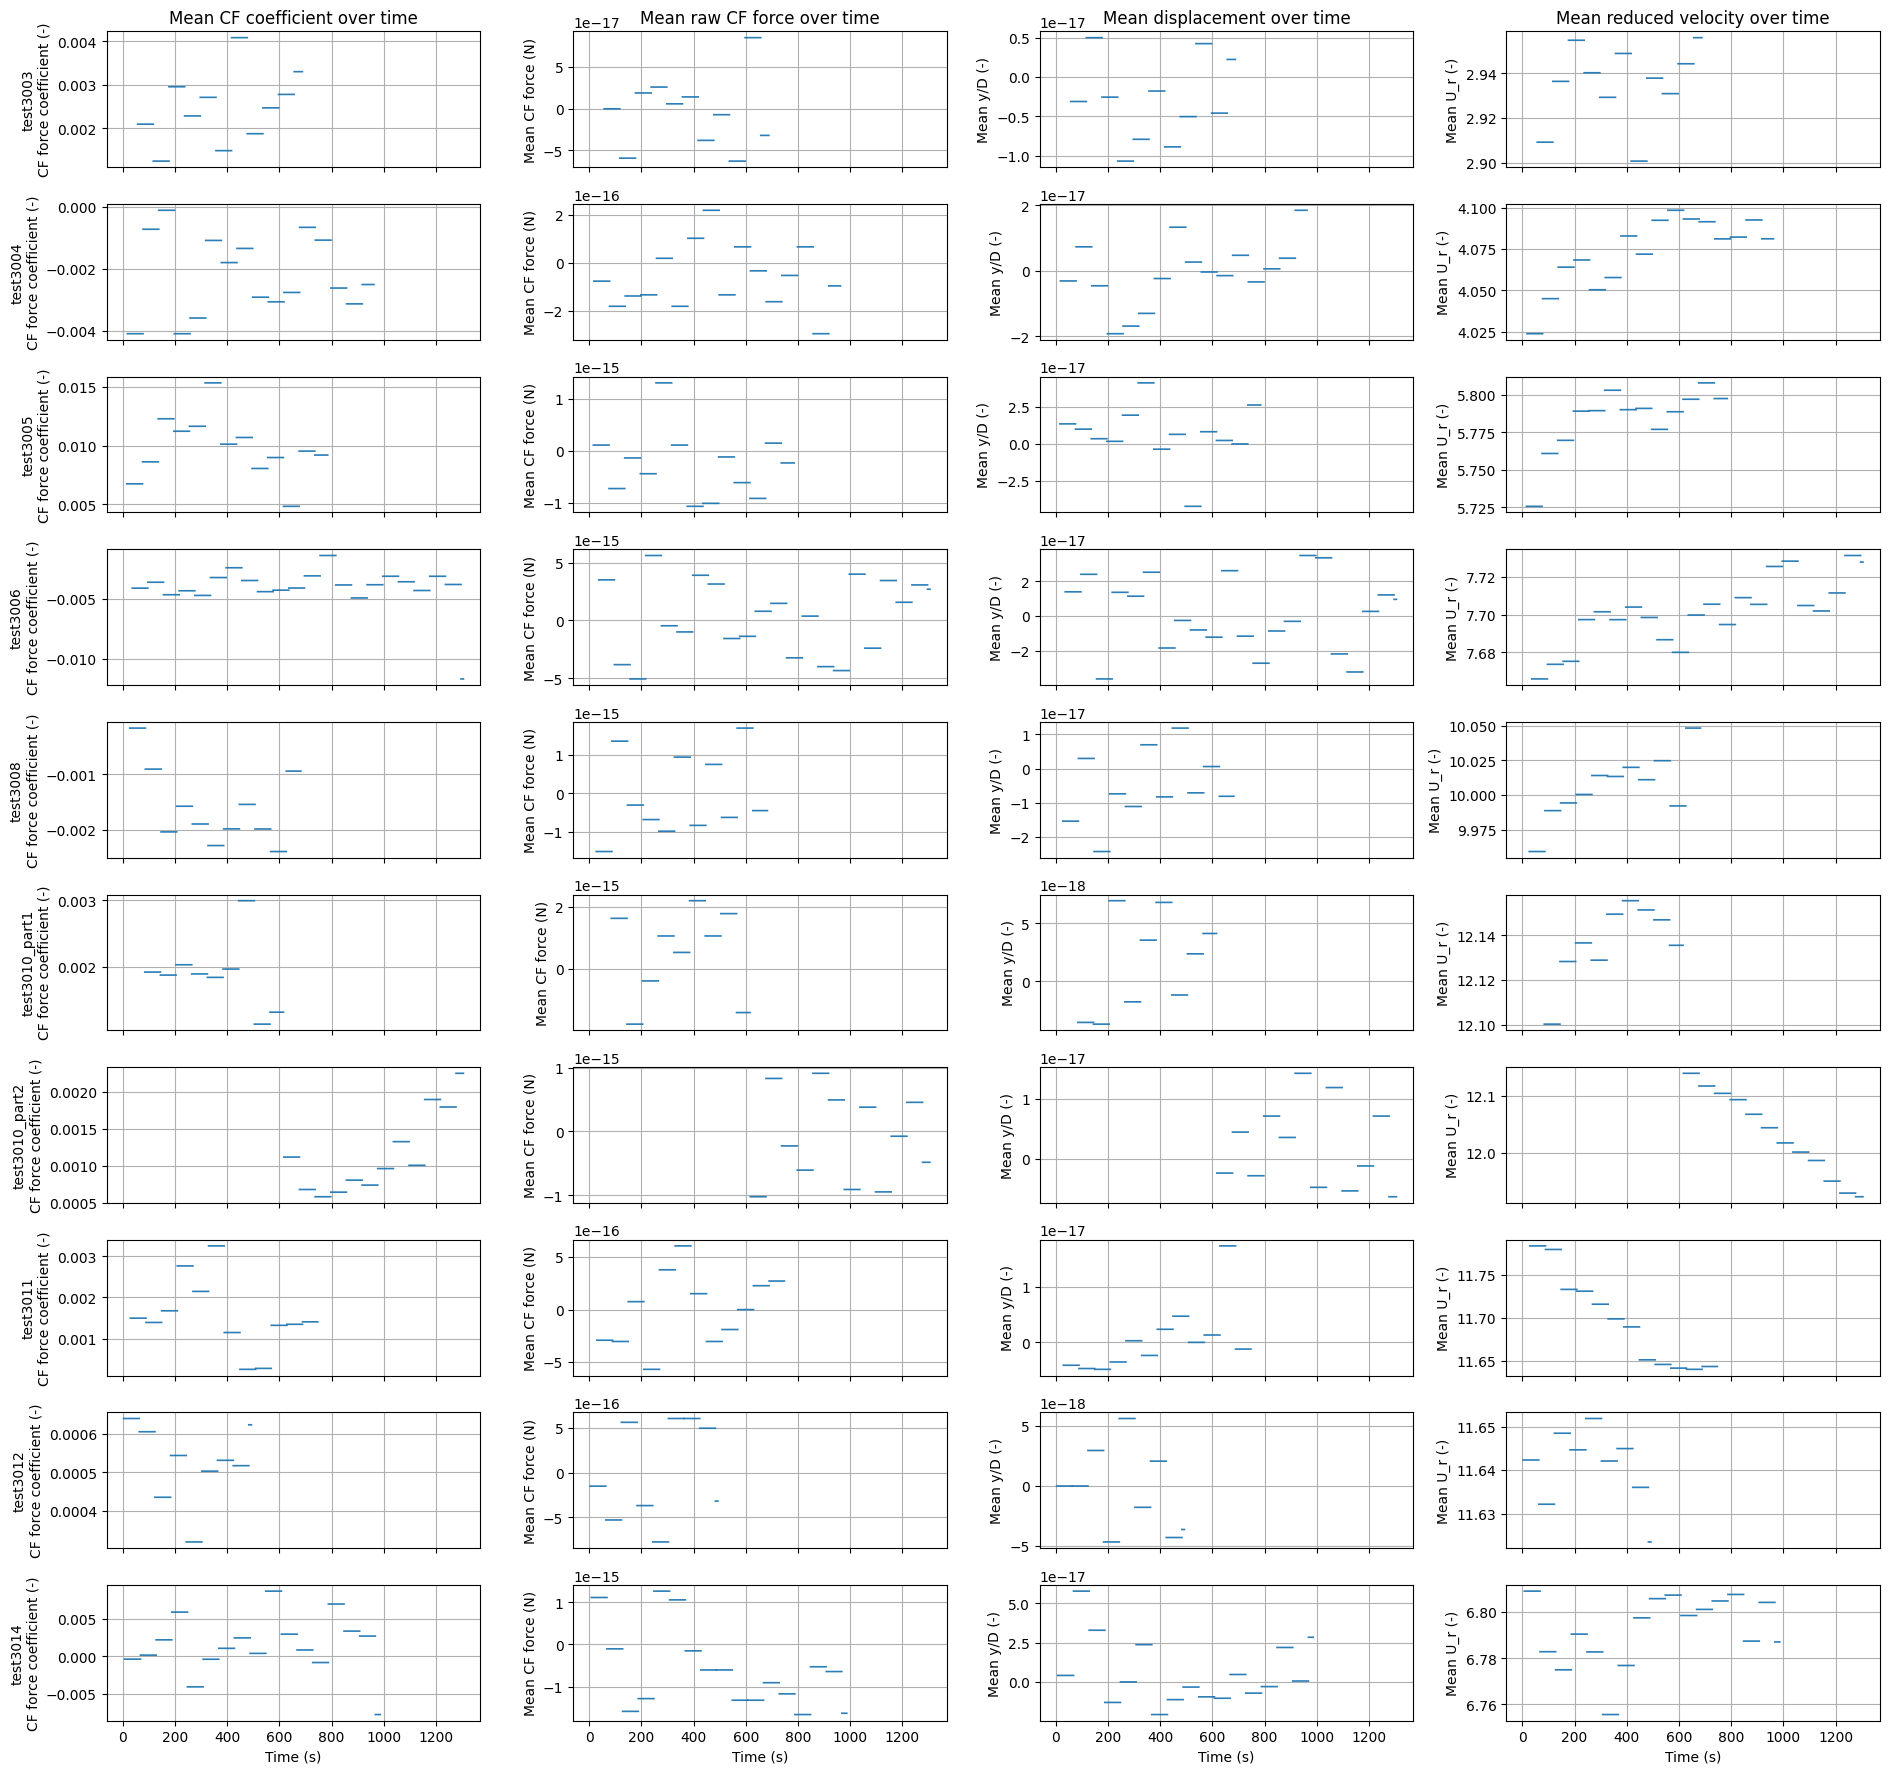

In [26]:
# Mean trends grouped by test (combine *_segXXX files in one row)
# Includes both CF coefficient mean and raw CF force mean.
MEAN_TS_WIDTH = 19
MEAN_TS_ROW_HEIGHT = 1.8
MEAN_TS_MIN_HEIGHT = 2.8
MEAN_TS_ALPHA = 0.95
MEAN_TS_LINEWIDTH = 1.2

if n_rows == 0:
    raise ValueError('No entries loaded. Run the data-prep cell first.')


def _base_test_label(label: str) -> str:
    return re.sub(r'_seg\d+$', '', str(label))


def _seg_index(label: str) -> int:
    m = re.search(r'_seg(\d+)$', str(label))
    return int(m.group(1)) if m else -1


# Group entries by test name (without _segXXX suffix).
groups = {}
for i, entry in enumerate(entries):
    base = _base_test_label(entry['label'])
    groups.setdefault(base, []).append((i, entry))


# Sort tests by numeric test id when possible.
def _test_sort_key(name: str):
    m = re.search(r'test(\d+)', str(name).lower())
    return (int(m.group(1)) if m else 10**9, str(name))


group_names = sorted(groups.keys(), key=_test_sort_key)
for base in group_names:
    groups[base] = sorted(groups[base], key=lambda pair: _seg_index(pair[1]['label']))


n_group_rows = len(group_names)
fig_mean, axes_mean = plt.subplots(
    n_group_rows,
    4,
    figsize=(MEAN_TS_WIDTH, max(MEAN_TS_ROW_HEIGHT * n_group_rows, MEAN_TS_MIN_HEIGHT)),
    sharex='col',
    squeeze=False,
)

axes_mean[0, 0].set_title('Mean CF coefficient over time')
axes_mean[0, 1].set_title('Mean raw CF force over time')
axes_mean[0, 2].set_title('Mean displacement over time')
axes_mean[0, 3].set_title('Mean reduced velocity over time')

for row, base in enumerate(group_names):
    ax_cf = axes_mean[row, 0]
    ax_cf_raw = axes_mean[row, 1]
    ax_y = axes_mean[row, 2]
    ax_ur = axes_mean[row, 3]

    base_color = colors[row % len(colors)]
    items = groups[base]

    for i, entry in items:
        t = np.asarray(entry['time_plot'], dtype=float)
        cf = np.asarray(entry['cfy'], dtype=float)
        cf_raw = np.asarray(entry['cfy_force'], dtype=float)
        y_nd = np.asarray(entry['y_nd'], dtype=float)
        ur = np.asarray(entry['ur_inst'], dtype=float)

        n = int(min(t.size, cf.size, cf_raw.size, y_nd.size, ur.size))
        if n < 2:
            continue

        t = t[:n]
        cf_mean = float(np.nanmean(cf[:n]))
        cf_raw_mean = float(np.nanmean(cf_raw[:n]))
        y_mean = float(np.nanmean(y_nd[:n]))
        ur_mean = float(np.nanmean(ur[:n]))

        seg_label = str(entry['label'])
        ax_cf.plot(
            t,
            np.full(n, cf_mean, dtype=float),
            color=base_color,
            alpha=MEAN_TS_ALPHA,
            linewidth=MEAN_TS_LINEWIDTH,
            label=seg_label,
        )
        ax_cf_raw.plot(
            t,
            np.full(n, cf_raw_mean, dtype=float),
            color=base_color,
            alpha=MEAN_TS_ALPHA,
            linewidth=MEAN_TS_LINEWIDTH,
        )
        ax_y.plot(
            t,
            np.full(n, y_mean, dtype=float),
            color=base_color,
            alpha=MEAN_TS_ALPHA,
            linewidth=MEAN_TS_LINEWIDTH,
        )
        ax_ur.plot(
            t,
            np.full(n, ur_mean, dtype=float),
            color=base_color,
            alpha=MEAN_TS_ALPHA,
            linewidth=MEAN_TS_LINEWIDTH,
        )

    ax_cf.grid(True)
    ax_cf_raw.grid(True)
    ax_y.grid(True)
    ax_ur.grid(True)

    ax_cf.set_ylabel(f"{base}\n{_cf_label()}")
    ax_cf_raw.set_ylabel('Mean CF force (N)')
    ax_y.set_ylabel('Mean y/D (-)')
    ax_ur.set_ylabel('Mean U_r (-)')

for j in range(4):
    axes_mean[-1, j].set_xlabel('Time (s)')

fig_mean.tight_layout()
plt.show()



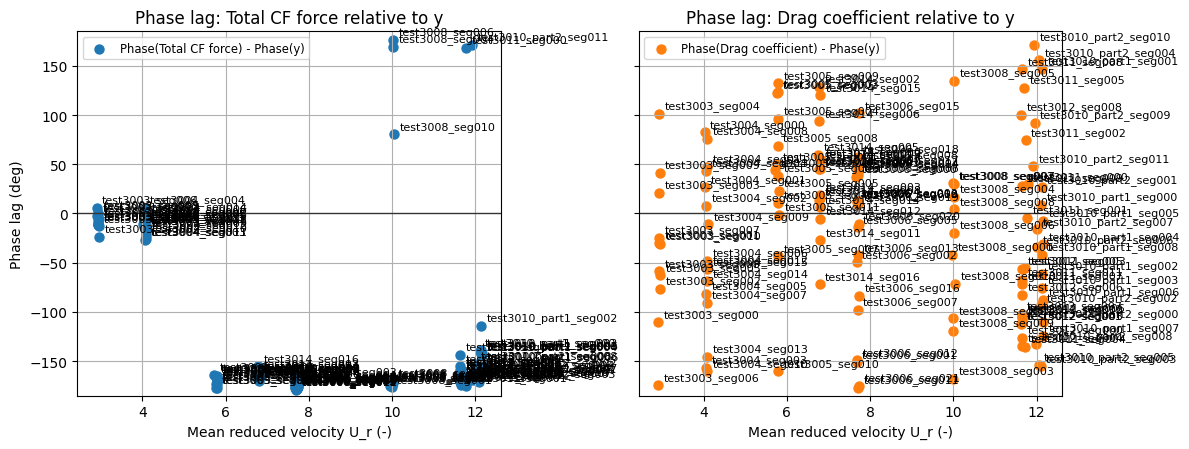

In [16]:
# Figure 8: phase lag vs reduced velocity
FIG8_SIZE = (12, 4.6)
PHASE_YLIM = (-185.0, 185.0)
ANNOTATE_POINTS = True

entries_sorted = sorted(entries, key=lambda e: float(e['summary']['ur']))
ur_vals = np.array([float(e['summary']['ur']) for e in entries_sorted], dtype=float)
labels_sorted = [str(e['label']) for e in entries_sorted]
phase_cfy_vals = np.array([float(e['summary']['phase_cfy_y_deg']) for e in entries_sorted], dtype=float)
phase_cdrag_vals = np.array([float(e['summary']['phase_cdrag_y_deg']) for e in entries_sorted], dtype=float)

fig8, (ax_p_cf, ax_p_cd) = plt.subplots(1, 2, figsize=FIG8_SIZE, sharey=True)

phase_cf_mask = np.isfinite(ur_vals) & np.isfinite(phase_cfy_vals)
ur_phase_cf = ur_vals[phase_cf_mask]
phase_cf = phase_cfy_vals[phase_cf_mask]
labels_phase_cf = [name for name, keep in zip(labels_sorted, phase_cf_mask) if keep]
ax_p_cf.scatter(
    ur_phase_cf,
    phase_cf,
    color='tab:blue',
    s=42,
    label=f"Phase({_cf_name()}) - Phase(y)",
)
ax_p_cf.axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
if ANNOTATE_POINTS:
    for x, yv, name in zip(ur_phase_cf, phase_cf, labels_phase_cf):
        ax_p_cf.annotate(name, (x, yv), textcoords='offset points', xytext=(4, 4), fontsize=8)
ax_p_cf.grid(True)
ax_p_cf.set_xlabel('Mean reduced velocity U_r (-)')
ax_p_cf.set_ylabel('Phase lag (deg)')
ax_p_cf.set_title(f"Phase lag: {_cf_name()} relative to y")
ax_p_cf.set_ylim(*PHASE_YLIM)
ax_p_cf.legend(loc='best', fontsize='small')

phase_cd_mask = np.isfinite(ur_vals) & np.isfinite(phase_cdrag_vals)
ur_phase_cd = ur_vals[phase_cd_mask]
phase_cd = phase_cdrag_vals[phase_cd_mask]
labels_phase_cd = [name for name, keep in zip(labels_sorted, phase_cd_mask) if keep]
ax_p_cd.scatter(
    ur_phase_cd,
    phase_cd,
    color='tab:orange',
    s=42,
    label=f"Phase({_drag_name()}) - Phase(y)",
)
ax_p_cd.axhline(0.0, color='black', linewidth=1.0, alpha=0.7)
if ANNOTATE_POINTS:
    for x, yv, name in zip(ur_phase_cd, phase_cd, labels_phase_cd):
        ax_p_cd.annotate(name, (x, yv), textcoords='offset points', xytext=(4, 4), fontsize=8)
ax_p_cd.grid(True)
ax_p_cd.set_xlabel('Mean reduced velocity U_r (-)')
ax_p_cd.set_title(f"Phase lag: {_drag_name()} relative to y")
ax_p_cd.legend(loc='best', fontsize='small')
fig8.tight_layout()
plt.show()
